# Take-home assignment - 2

Problem Statement:

This notebook contains an implementation of an OCR model on Python (Caffe). It is a modification of the [CRNN](https://arxiv.org/pdf/1507.05717) architecture.


The following 3 tasks have to be worked on using this trained model:


1. Ensure the OCR output does not have any duplicate character predictions. (This is how CRNN predicts normally, it’s fixed in post-OCR correction)


For eg,
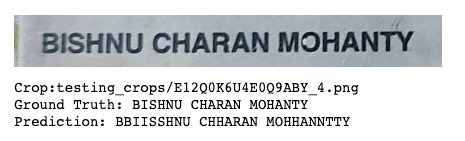




2. Calculate a single probability score for each OCR prediction, which gives an estimate of the confidence of the model in its prediction. Along with the confidence value, a reasonable conf threshold should also be chosen to optimize for high precision and recall.


3. Write an algorithm to predict each character’s region within a single crop, and mask a part of the text image.

For eg, masking ‘CHARAN’ in the following image using character regions

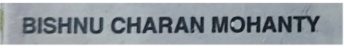

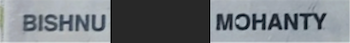



Along with the code, you will find some sample text crops that can be used for testing.

  - Each image has a corresponding `.txt` file and `.pkl` file. The text file contains the ground truth for the image where as the Pickle file contains the softmax values of the CRNN model.


### The below cell consists of code that is required to initiate and setup the assignment for you. Please run it before you move ahead.

In [1]:
# Initiation code.

# Required Imports
from collections import OrderedDict
from IPython.display import Image, display
import os
import cv2
import numpy as np
import pickle




In [2]:
#HELPER FUNCTIONS.

# Charset consists of 74 characters + NULL (which is the 75th character)
CHARSET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789 /-,.:<&()#;'

'''
get_softmax function takes in image name
returns image and CRNN softmax values for each timestep for the image.
Hint: Get a clear understanding of timestep concept in CRNN
'''
def get_softmax(image_name):

    img = cv2.imread(image_name)
    gt = open(image_name + '.txt').readlines()[0]
    softmax = pickle.load(open(image_name+".pkl", "rb"))
    return img, gt, softmax

"""
process function takes in softmax value.
Returns predicted output_text, single confidence score for the image's prediction, character regions
1. Make all changes here to output correct probabilities and regions.
2. Because of the timestep concept, character repetitions can occur (check predictions).
    Make necessary modifications to fix this.
"""
# def process(softmax):

#     seq_len = softmax.shape[0]

#     decoded = np.argmax(softmax, axis = 1)

#     output_text = []
#     output_prob = 1.0
#     output_text_regions = []

#     for i in range(seq_len):
#         # Last character is a NULL token (Last node in softmax layer)
#         if decoded[i] != len(CHARSET):
#             output_text.append(CHARSET[decoded[i]])

#     output_text = ''.join(output_text)

#     return output_text, output_prob, output_text_regions


#### functions defined below : remove_blanks_duplicates() compute_confidence_selected_chars(), get_char_regions()

def process(softmax,img_width):

    output_text = remove_blanks_duplicates(softmax, CHARSET)
    output_prob = compute_confidence_selected_chars(softmax, CHARSET)
    output_text_regions = get_char_regions(softmax, CHARSET, img_width)

    return output_text, output_prob, output_text_regions


"""
    Input to CRNN is always of height 32px while the width might vary.
    Any input of width Y will have Y/4 timesteps in the sequence.
    Thus, an input of shape Y x 32 will be divided into Y/4 timesteps, each of shape 4 x 32
"""
def width_to_seq_len(width, epsilon=0.0001):
    return int(width / (4 + epsilon))

"""
Preprocess function that was used to process images before feedforwarding through the CRNN net
"""
def preProcessImages(images_test):
    if len(images_test) == 0:
        return []

    images_out = []
    for i in range(len(images_test)):
        img = 1.0 * cv2.cvtColor(images_test[i], cv2.COLOR_BGR2GRAY) / 255.0

        resize_factor = 1.0 * 32 / img.shape[0]
        out_width = int(img.shape[1] * resize_factor)

        # Minimum length required for processing
        if out_width < 41:
            out_width = 41

        img = cv2.resize(img, (out_width, 32))
        images_out.append(img)

    return images_out




#########################################################   CALCULATE METRICS   ###################################################################################################################.

def calculate_metrics(gt, output, conf, conf_threshold):
    """Calculate metrics for all prediction."""

    # Instructions for Matching Ground Truth (gt) with Predicted Outputs (output) using Confidence Scores (conf):

    # - gt: List of ground truth words, e.g., gt = ['hello', 'world']
    # - output: List of predicted words, e.g., output = ['hllo', 'world']
    # - conf: List of confidence scores for each prediction, e.g., conf = [0.9, 0.9]


       # SET conf_threshold after f1 score sweep
    precision = 0
    recall = 0
    accuracy = 0

    #True Positives -> gt is equal to output and confidence is above threshold
    #False Positives -> gt is not equal to output and confidence is above threshold
    #True Negatives -> gt is not equal to output and confidence is below threshold
    #False Negatives -> gt is equal to output and confidence is below threshold

    """write code here to measure the precision, recall, and accuracy of the predictions"""

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    total = len(gt)

    for i in range(total):
        ground_truth_word = gt[i]
        predicted_word = output[i]
        confidence_score = conf[i]
        is_correct = False
        
        if ground_truth_word == predicted_word:
            is_correct = True
        is_above_threshold = False
        if confidence_score >= conf_threshold:
            is_above_threshold = True
        if is_correct == True and is_above_threshold == True:
            tp = tp + 1
        elif is_correct == False and is_above_threshold == True:
            fp = fp + 1
        elif is_correct == False and is_above_threshold == False:
            tn = tn + 1
        elif is_correct == True and is_above_threshold == False:
            fn = fn + 1

    # precision = tp / (tp + fp)
    if (tp + fp) > 0:
        precision = tp / (tp + fp)

    # recall = recall = tp / (tp + fn)
    if (tp + fn) > 0:
        recall = tp / (tp + fn)
    
    # accuracy = all correct prediction divided by total number of predictions
    if total > 0:
        accuracy = (tp + tn) / total

    return precision, recall, accuracy

### The following cell will help you visualize the input image, ground truth and prediction of the CRNN model for the respective image.

In [3]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
model_outputs_path = NOTEBOOK_DIR / "testing_crops"

if not model_outputs_path.exists():
    model_outputs_path = NOTEBOOK_DIR / "assignment-2" / "testing_crops"

print("Using testing_crops from:", model_outputs_path)
print("Exists:", model_outputs_path.exists())

crops = [el for el in sorted(os.listdir(model_outputs_path)) if 'txt' not in el and 'pkl' not in el]
print(len(crops))


              # Predicted output


Using testing_crops from: /Users/avijitkundal/Downloads/hyperverge-assignment-main/assignment-2/testing_crops
Exists: True
566



> Task 1 - Ensure the OCR output does not have any duplicate character predictions


In [4]:
def remove_blanks_duplicates(softmax, charset):

    ## all we need to do it detect repeating characters in the output array which are not seperated by a blank and remove them and the blanks
    # the model outputs softmax which is a probability distribution over all characters so we take the class with max probability for each timestep/slice

    
    blank_idx = len(charset)
    preds = np.argmax(softmax, axis=1)
    
    decoded = []
    prev = None

    for p in preds:
        if p == prev:
            continue
        if p != blank_idx:
            decoded.append(charset[p])
        prev = p
    return ''.join(decoded)


for idx in range(25):

    img, gt, softmax = get_softmax(str(model_outputs_path / crops[idx]))


    pred = remove_blanks_duplicates(softmax, CHARSET)
    print("GT:", gt)
    print("Pred:", pred)
    print("#########################################################")
    

GT: Maharashtra - 411031
Pred: Maharashtra - 411031
#########################################################
GT: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Pred: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
#########################################################
GT: IBAPK0918J
Pred: IBAPK0918J
#########################################################
GT: RAMCHANDRA SONAR
Pred: RAMCHANDRA SONAR
#########################################################
GT: 1800 300 1947
Pred: 1800 300 1947
#########################################################
GT: Town/City: Mallappally,
Pred: Town/City: Mallappall),
#########################################################
GT: 29/12/1995
Pred: 29/12/1995
#########################################################
GT: ARJUNSINH JADAV
Pred: ARJUNSINH JADAV
#########################################################
GT: Bengaluru-560 001
Pred: Bengaluru-560 001
#########################################################
GT: 1947
Pred: 1947
######################


> Task 2 - Calculate a single probability score for each OCR prediction, which gives an estimate of the confidence of the model in its prediction. Along with the confidence value, a reasonable conf threshold should also be chosen to optimize for high precision and recall


In [5]:
def compute_confidence_selected_chars(softmax, charset):

    ## since softmax already gives us probabilties we should use them
    ## We can take an average of the probabilities of the selected charcters but a better apporach would be to multiply them so that low probbablity characters have a stronger impact 
    ## a single incorrect character can make the entire string incorrect so we wanna use a mechanism which punishes mistakes more than it rewards correctness
    ## since characters can of off varied lenghts we wanna normalize the length 
    ## since multipling probabilities can lead to very small numbers its better to use log probabilites and add them and exponentiate back to get probabilities


    blank_idx = len(charset)
    preds = np.argmax(softmax, axis=1)

    log_conf = 0.0
    count = 0

    prev = None
    for index, logits in enumerate(preds):
        if logits == prev:
            prev = logits
            continue
        if logits != blank_idx:
            prob = softmax[index][logits]          
            ## avoid log 0
            prob = max(prob, 0.000001)
            log_conf += np.log(prob)
            count += 1
        prev = logits

    if count == 0:
        return 0.0

    length_normalized_log_prob = log_conf / count

    # bring back to 0-1
    return np.exp(length_normalized_log_prob)




for idx in range(10):
    img, gt, softmax = get_softmax(str(model_outputs_path / crops[idx]))
  
    pred = remove_blanks_duplicates(softmax, CHARSET)
    conf = compute_confidence_selected_chars(softmax, CHARSET)

    print("GT:", gt)
    print("Pred:", pred)
    print("Confidence:", conf)

    print("#########################################################")


     

GT: Maharashtra - 411031
Pred: Maharashtra - 411031
Confidence: 0.9973934
#########################################################
GT: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Pred: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Confidence: 0.9784633
#########################################################
GT: IBAPK0918J
Pred: IBAPK0918J
Confidence: 0.9954461
#########################################################
GT: RAMCHANDRA SONAR
Pred: RAMCHANDRA SONAR
Confidence: 0.99769133
#########################################################
GT: 1800 300 1947
Pred: 1800 300 1947
Confidence: 0.9905101
#########################################################
GT: Town/City: Mallappally,
Pred: Town/City: Mallappall),
Confidence: 0.8815092
#########################################################
GT: 29/12/1995
Pred: 29/12/1995
Confidence: 0.9996311
#########################################################
GT: ARJUNSINH JADAV
Pred: ARJUNSINH JADAV
Confidence: 0.991034
############################

In [6]:

####################### FIND THRESHOLD ################

# to balance precision and recall we can use a metric like f1 score..sweep different values of threshold and choose threshold which maximizes f1 score



gts = []
preds = []
confs_list = []

for idx in range(len(crops)):
    img, gt, softmax = get_softmax(str(model_outputs_path / crops[idx]))

    pred = remove_blanks_duplicates(softmax, CHARSET)
    conf = compute_confidence_selected_chars(softmax, CHARSET)

    gts.append(gt)
    preds.append(pred)
    confs_list.append(conf)

thresholds = np.linspace(0.4, 1, 100)
best_t = 0
best_f1 = 0


for t in thresholds:

    tp = 0
    fp = 0
    fn = 0

    total = len(gts)

    for i in range(total):
        is_correct = False
        if gts[i] == preds[i]:
            is_correct = True
        is_above = False
        if confs_list[i] >= t:
            is_above = True
        if is_correct == True and is_above == True:
            tp += 1
        elif is_correct == False and is_above == True:
            fp += 1
        elif is_correct == True and is_above == False:
            fn += 1
    
    # precision = tp / (tp + fp)
    precision = 0
    if (tp + fp) > 0:
        precision = tp / (tp + fp)
    
    # recall = tp / (tp + fn)
    recall = 0
    if (tp + fn) > 0:
        recall = tp / (tp + fn)

    f1 = 0
    if (precision + recall) > 0:
        f1 = 2 * precision * recall / (precision + recall)

    if t> 0.90:

        print("threshold:", t, "Precision:", precision, "Recall:", recall, "F1:", f1)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t


print("Best threshold:", best_t)
print("Best F1:", best_f1)        

threshold: 0.9030303030303031 Precision: 0.8175965665236051 Recall: 0.9670050761421319 F1: 0.8860465116279069
threshold: 0.9090909090909091 Precision: 0.8307692307692308 Recall: 0.9593908629441624 F1: 0.8904593639575972
threshold: 0.9151515151515152 Precision: 0.8404494382022472 Recall: 0.949238578680203 F1: 0.8915375446960667
threshold: 0.9212121212121213 Precision: 0.8525345622119815 Recall: 0.9390862944162437 F1: 0.893719806763285
threshold: 0.9272727272727272 Precision: 0.8672985781990521 Recall: 0.9289340101522843 F1: 0.8970588235294118
threshold: 0.9333333333333333 Precision: 0.8759124087591241 Recall: 0.9137055837563451 F1: 0.8944099378881988
threshold: 0.9393939393939394 Precision: 0.8875 Recall: 0.9010152284263959 F1: 0.8942065491183878
threshold: 0.9454545454545454 Precision: 0.8891752577319587 Recall: 0.8756345177664975 F1: 0.8823529411764706
threshold: 0.9515151515151515 Precision: 0.9054054054054054 Recall: 0.850253807106599 F1: 0.8769633507853403
threshold: 0.957575757575

In [7]:
# BEST F1
precision, recall, accuracy = calculate_metrics(gts, preds, confs_list, best_t)
print("######## FOR BEST F1 Score ##########")
print("Using threshold:", best_t)
print("PRECISION :", precision)
print("RECALL :", recall)
print("ACCURACY :", accuracy)

print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')


# BEST PRECISION
best_prec = 0
best_t_prec = 0

for t in thresholds:
    precision, recall, accuracy = calculate_metrics(gts, preds, confs_list, t)
    if precision > best_prec:
        best_prec = precision
        best_t_prec = t

precision, recall, accuracy = calculate_metrics(gts, preds, confs_list, best_t_prec)

print("######## FOR BEST PRECISION ##########")
print("Using threshold:", best_t_prec)
print("PRECISION :", precision)
print("RECALL :", recall)
print("ACCURACY :", accuracy)

print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')


# BEST ACCURACY
best_acc = 0
best_t_acc = 0

for t in thresholds:
    precision, recall, accuracy = calculate_metrics(gts, preds, confs_list, t)
    if accuracy > best_acc:
        best_acc = accuracy
        best_t_acc = t

precision, recall, accuracy = calculate_metrics(gts, preds, confs_list, best_t_acc)

print("######## FOR BEST ACCURACY ##########")
print("Using threshold:", best_t_acc)
print("PRECISION :", precision)
print("RECALL :", recall)
print("ACCURACY :", accuracy)

######## FOR BEST F1 Score ##########
Using threshold: 0.9272727272727272
PRECISION : 0.8672985781990521
RECALL : 0.9289340101522843
ACCURACY : 0.8515901060070671
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
######## FOR BEST PRECISION ##########
Using threshold: 0.9878787878787879
PRECISION : 0.9587628865979382
RECALL : 0.4720812182741117
ACCURACY : 0.6183745583038869
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
######## FOR BEST ACCURACY ##########
Using threshold: 0.9272727272727272
PRECISION : 0.8672985781990521
RECALL : 0.9289340101522843
ACCURACY : 0.8515901060070671



> Task 3 - Write an algorithm to predict each character’s region within a single crop, and mask a part of the text image



GT: Maharashtra - 411031
Pred: Maharashtra - 411031
------------------------------------------------


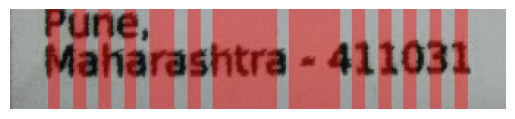

GT: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Pred: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
------------------------------------------------


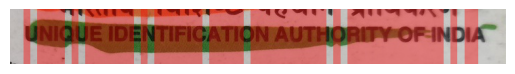

GT: IBAPK0918J
Pred: IBAPK0918J
------------------------------------------------


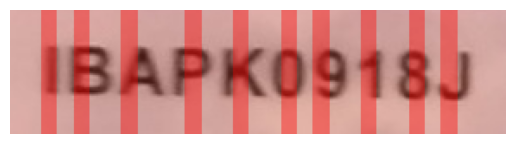

GT: RAMCHANDRA SONAR
Pred: RAMCHANDRA SONAR
------------------------------------------------


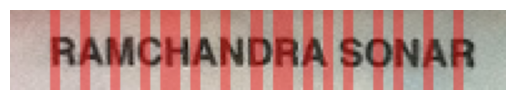

GT: 1800 300 1947
Pred: 1800 300 1947
------------------------------------------------


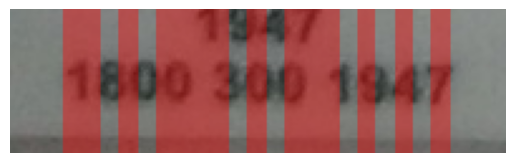

GT: Town/City: Mallappally,
Pred: Town/City: Mallappall),
------------------------------------------------


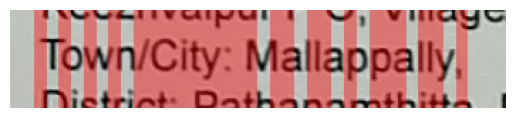

GT: 29/12/1995
Pred: 29/12/1995
------------------------------------------------


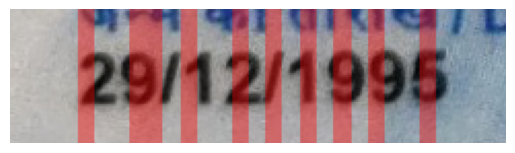

GT: ARJUNSINH JADAV
Pred: ARJUNSINH JADAV
------------------------------------------------


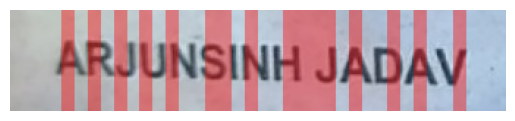

GT: Bengaluru-560 001
Pred: Bengaluru-560 001
------------------------------------------------


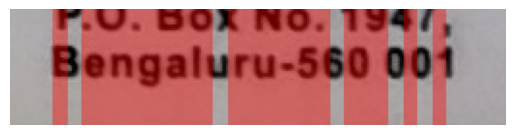

GT: 1947
Pred: 1947
------------------------------------------------


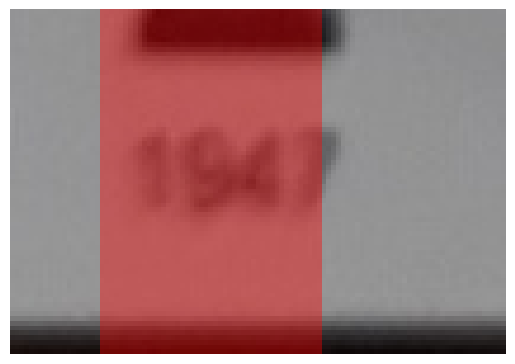

In [8]:
import cv2
import matplotlib.pyplot as plt

## since in CRNN each vertical slice corresponds to a timestep, all we need to do is find the timesteps of characters that remain after remove_blanks_duplicates()
## those timesteps give us image regions which we can mask
## incase of repeating character we wanna mask both regions till a blank_idx appears

def get_char_regions(softmax, charset, img_width):

    blank_idx = len(charset)
    preds = np.argmax(softmax, axis=1)

    slice_width = img_width / len(preds)
    regions = []
    start = None

    for i in range(len(preds)):
        # starting charcater which is not blank or repeating
        if preds[i] != blank_idx and (i == 0 or preds[i] != preds[i-1]):
            start = i
        # end when no next character is different or no next character
        if preds[i] != blank_idx and (i == len(preds)-1 or preds[i] != preds[i+1]):
            end = i + 1
            regions.append((int(start * slice_width), int(end * slice_width)))

    return regions


def overlay_text_regions(img, regions, alpha=0.4):

    out = img.copy()

    for (x1, x2) in regions:
        patch = np.zeros_like(img[:, x1:x2])
        patch[:, :, 2] = 255
        out[:, x1:x2] = cv2.addWeighted(
            img[:, x1:x2], 1 - alpha,
            patch, alpha,
            0)

    return out



for idx in range(10):
    img, gt, softmax = get_softmax(str(model_outputs_path / crops[idx]))
    pred = remove_blanks_duplicates(softmax, CHARSET)
    print("GT:", gt)
    print("Pred:", pred)
    print("------------------------------------------------")
    regions = get_char_regions(softmax, CHARSET, img.shape[1])
    vis = overlay_text_regions(img, regions, alpha=0.4)
    vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.imshow(vis)
    plt.axis('off')
    plt.show()

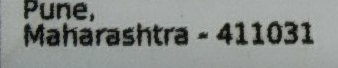

Crop: 02LG1LOETLZTUU9N_10.png
Ground Truth: Maharashtra - 411031
Prediction: Maharashtra - 411031


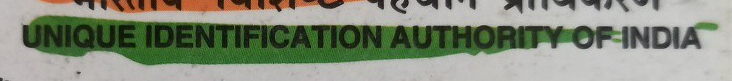

Crop: 02SCI7TGBB8R2KV7_1.png
Ground Truth: UNIQUE IDENTIFICATION AUTHORITY OF INDIA
Prediction: UNIQUE IDENTIFICATION AUTHORITY OF INDIA


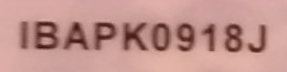

Crop: 050TN14UKIIH8YBD_4.png
Ground Truth: IBAPK0918J
Prediction: IBAPK0918J


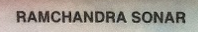

Crop: 05ZXR2UZ18SZR7E5_3.png
Ground Truth: RAMCHANDRA SONAR
Prediction: RAMCHANDRA SONAR


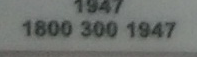

Crop: 09CDR6OPN2VMLP7P_19.png
Ground Truth: 1800 300 1947
Prediction: 1800 300 1947


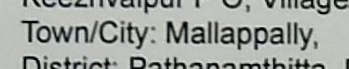

Crop: 09WEHLJPO25V57TD_11.png
Ground Truth: Town/City: Mallappally,
Prediction: Town/City: Mallappall),


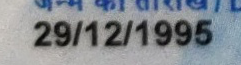

Crop: 0AZRYZIU3IXFFKLN_14.png
Ground Truth: 29/12/1995
Prediction: 29/12/1995


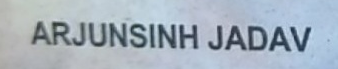

Crop: 0BQ5XVZFYVCEUNDN_4.png
Ground Truth: ARJUNSINH JADAV
Prediction: ARJUNSINH JADAV


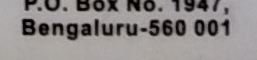

Crop: 0DPCGBUT8R5DI6NZ_22.png
Ground Truth: Bengaluru-560 001
Prediction: Bengaluru-560 001


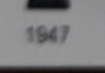

Crop: 0FR1KSAZKK8WVCKD_12.png
Ground Truth: 1947
Prediction: 1947


In [9]:
# Displaying the details of the first 10 samples
for idx in range(10):
    display(Image(filename = str(model_outputs_path / crops[idx])))
    print('Crop: ' + crops[idx])                        # Crop name

    img, gt, softmax = get_softmax(str(model_outputs_path / crops[idx]))
    print('Ground Truth: ' + gt)                        # Ground truth

    outputs, confs, char_regions = process(softmax, img.shape[1])
    print('Prediction: ' + outputs)       